In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import math
from matplotlib.scale import FuncScale

from pathlib import Path

from os.path import join
import os
from functools import partial
import pathlib
import shutil

import re


In [13]:
# model_comparisons = [
#     "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts_workshop",
#     "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big/forecasts",
#     # "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_big3/forecasts",
#     # "/glade/derecho/scratch/dkimpara/goes_10km_train/20m_inv/forecasts",
#     "/glade/derecho/scratch/dkimpara/goes_10km_train/30m_omid/forecasts",
# ]
model_comparisons = [
    "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts_2025_eval",
]

model_comparisons = {
    Path(d).parent.name: d for d in model_comparisons
}


baselines = {
    # "10m_big_2022":  "/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts_workshop",
    "30m_mpas":  "/glade/derecho/scratch/dkimpara/goes_10km_train/mpas/mpas_fixed",
    "10m_climo": "/glade/derecho/scratch/dkimpara/goes_10km_train/baselines/climo_forecasts",
    "10m_persistence": "/glade/derecho/scratch/dkimpara/goes_10km_train/baselines/persistence_forecasts",
}
comparisons = baselines | model_comparisons




colors = {
    "10m_persistence": "0",
    "10m_climo": "0.5",
    "10m_big": "r",
    "20m_big": "g",
    "30m_omid": "b",
    "30m_mpas": "c",
} #defaults to None in .get


linestyles = {
    "10m_persistence": "--",
    "00z": ":",
    "06z": "-.",
    "12z": "--",
    "18z": (0, (3, 5, 1, 5, 1, 5)),
} #defaults to None in .get

dfs = {k: pd.read_parquet(join(path, "verif.parquet")) for k, path in comparisons.items()}

dfs_init_time = {}
# add by init_hour
for model in ["10m_big", "30m_mpas", "10m_persistence"]:
    for t in [0,6,12,18]:
        dfs_init_time[f"{model}_{t:02}z"] = pd.read_parquet(join(comparisons[model], f"verif_T{t:02}z.parquet"))


# dfs = {k: df[df["forecast_step"] != 21.0] for k, df in dfs.items()}

# dfs_all = {k: [pd.read_parquet(p) for p in Path(v).iterdir() if (p != "verif.parquet") and "parquet" in p.name] 
#            for k,v in comparisons.items()}

In [14]:
def plot_1d_metric(metric, channel, right_lim=None, top_lim=None):
    col_name = f"{metric}_C{channel:02}"
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for model, df in dfs.items():
        timestep = int(model[:2]) / 60.
        ax.plot(df.forecast_step * timestep, df[col_name],
                # label=model,
                color=colors.get(model, None), linestyle=linestyles.get(model, None))
        if "climo" not in model:
            for t in [0,6,12,18]:
                df = dfs_init_time[f"{model}_{t:02}z"]
                ax.plot(df.forecast_step * timestep, df[col_name],
                        # label=model,
                        color=colors.get(model, None), linestyle=linestyles.get(f"{t:02}z", None))

    for t in [0,6,12,18]:
        ax.plot([],[], label=f"{t:02}z init", linestyle=linestyles.get(f"{t:02}z", None), c="0")
    
    plt.legend()
    ticks = [0.5] + [int(k) for k in range(1, math.ceil(max(df.forecast_step) * timestep + 1))]
    ax.set_xticks(ticks)
    
    ax.grid()
    # ax.legend()

    ax.set_xlim(left=0.0,right=right_lim)
    if metric != "ME":
        ax.set_ylim(bottom=0.0, top=top_lim)
    else:
        ax.axhline(0.0, color="0")

    ax.set_xlabel('Forecast hour')
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} C{channel:02}")
    plt.show()


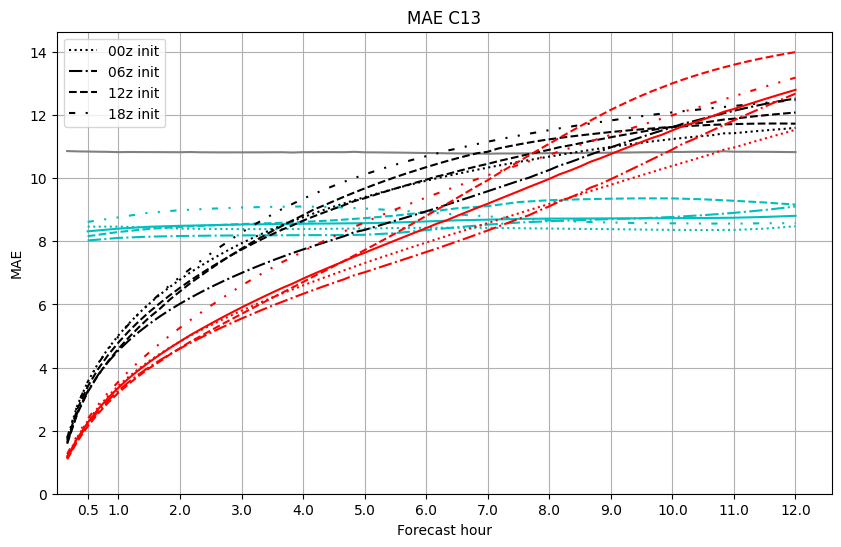

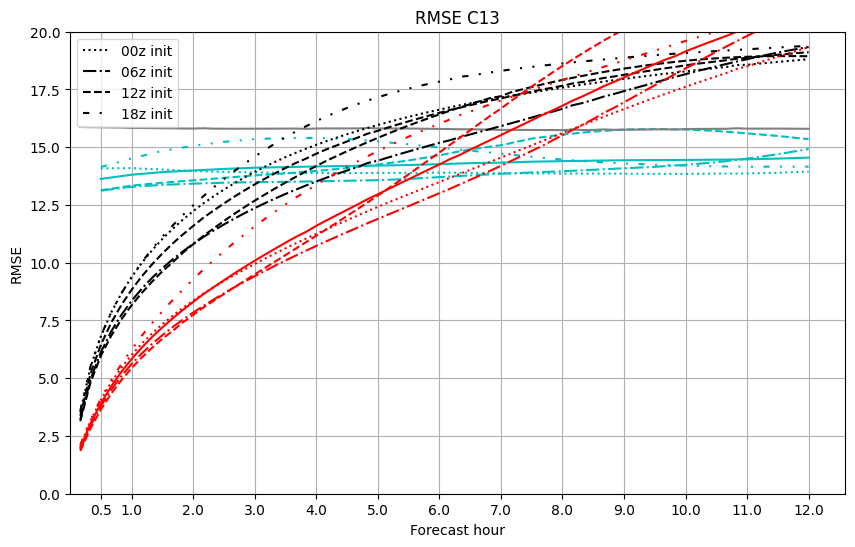

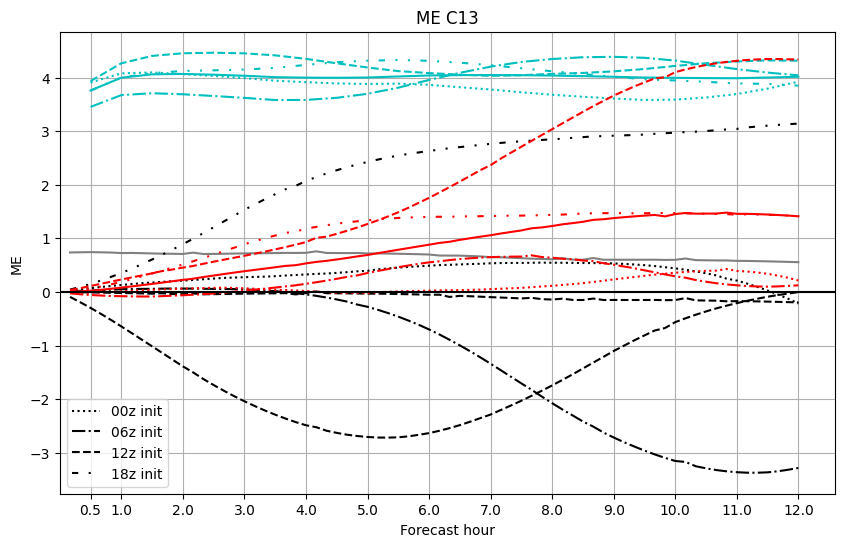

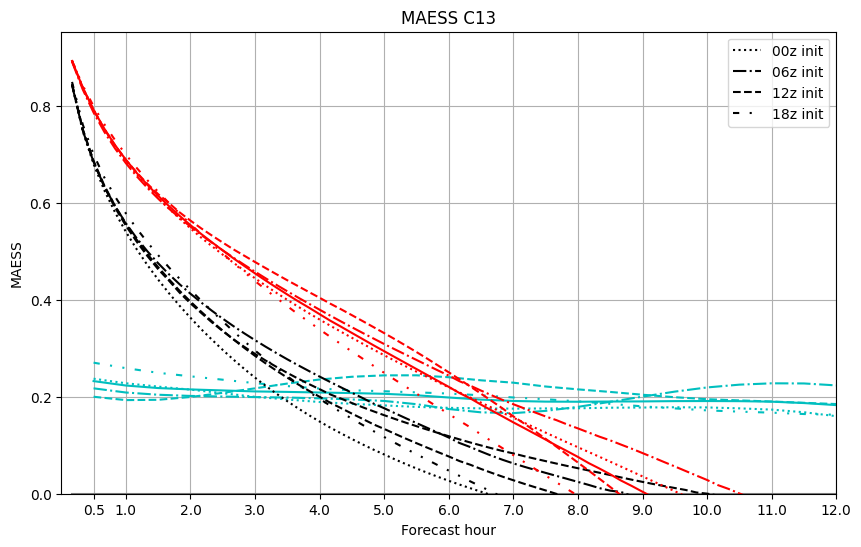

In [15]:
plot_1d_metric("MAE", 13)
plot_1d_metric("RMSE", 13,  top_lim = 20)
plot_1d_metric("ME", 13)
plot_1d_metric("MAESS", 13, 12)

In [16]:
def fss_plot(df, timestep, channel, fss_types, titles=None,
             percentile=False, tropics=False, suptitle=None):
    # With spacing control
    num_subplots = len(fss_types)
    fig, axes = plt.subplots(1, num_subplots, figsize=(5 * num_subplots, 4), sharey=True)
    fig.subplots_adjust(wspace=0.05)  # tighten horizontal gap

    axes[0].set_ylabel('Spatial scale (km)')

    for i, fss_type in enumerate(fss_types):
        ax = axes[i]
        # --- parse window sizes from column names ---
        def parse_window(col):
            m = re.search(f'WS(\d+)_C{channel:02}', col)
            return int(m.group(1)) if m else None

        fss_cols = [c for c in df.columns if c.startswith('FSS_WS') and c.endswith(f"C{channel:02}_{"PCT_" if percentile else ""}{fss_type}{"_tropics" if tropics else ""}")]
        windows  = np.array([parse_window(c) for c in fss_cols])

        # --- build matrix: rows=window sizes, cols=lead times ---
        lead_times = df.forecast_step * timestep / 60 # hours
        fss_matrix = df[fss_cols].values.T     # shape (n_windows, n_leads)

        windows_km = windows * 11
        y_values = windows_km
        # print(windows_km)
        # Map your values to [0, 1, 2, 3, ...] evenly
        def forward(y):
            return np.interp(y, y_values, np.arange(len(y_values)))

        def inverse(y):
            return np.interp(y, np.arange(len(y_values)), y_values)


        # mesh = ax.pcolormesh(x_edges, y_edges, fss_matrix, cmap='viridis_r', vmin=0, vmax=1, levels=levels)
        # cbar = plt.colorbar(mesh, ax=ax, label='FSS')
        # ax.set_ylim(y_edges[0], y_edges[-1])
        interval = 0.05
        levels = np.arange(0, 1 + interval, interval)
        cf = ax.contourf(lead_times, windows_km, fss_matrix,
                        levels=levels,
                        cmap='viridis')

        # get and plot skillful baseline
        skillful_threshold = 0.5 + df[f"obs_freq_C{channel:02}_{"PCT_" if percentile else ""}{fss_type}"].mean() / 2
        # print(skillful_threshold)
        contour_line = ax.contour(lead_times, windows_km, fss_matrix, levels=[skillful_threshold],  # use windows_km here
                colors='black', linewidths=1.5, linestyles='dotted')
        ax.clabel(contour_line, inline=True, inline_spacing=0, fontsize=10, fmt='%.2f', manual=False)
        # ax.pcolormesh(fss_matrix)
        # ax.set_yscale("log")

        ax.set_yscale(FuncScale(ax.yaxis, (forward, inverse)))
        # ax.set_yscale("log")
        # ax.set_yticks(y_values)
        ax.set_ylim(11, windows_km[-1] + 50) 


        ticks = [11, 25, 50, 75, 100, 150, 250, 500, 750, 1000, 1500, 2500]
        tick_labels = [10, 25, 50, 75, 100, 150, 250, 500, 750, 1000, 1500, 2500]
        ax.set_yticks(ticks)
        ax.set_yticklabels(tick_labels)

        ticks = list(range(1,13))
        ax.set_xticks(ticks)

        ax.set_xlabel('Lead time (hour)')

        ax.set_title(titles[i])
    fig.suptitle(suptitle)
    cbar = fig.colorbar(cf, ax=axes, location='right', pad=0.02, label="Fractional Skill Score")
    # fig.subplots_adjust(right=0.88)
    # cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    # fig.colorbar(cf, cax=cbar_ax, label="Fractional Skill Score")
    # plt.tight_layout()
    plt.show()

def get_fss_types(df, channel):
    return sorted(set(re.search(rf'C{channel:02}_(.+)$', c).group(1) for c in df.columns if "FSS" in c))




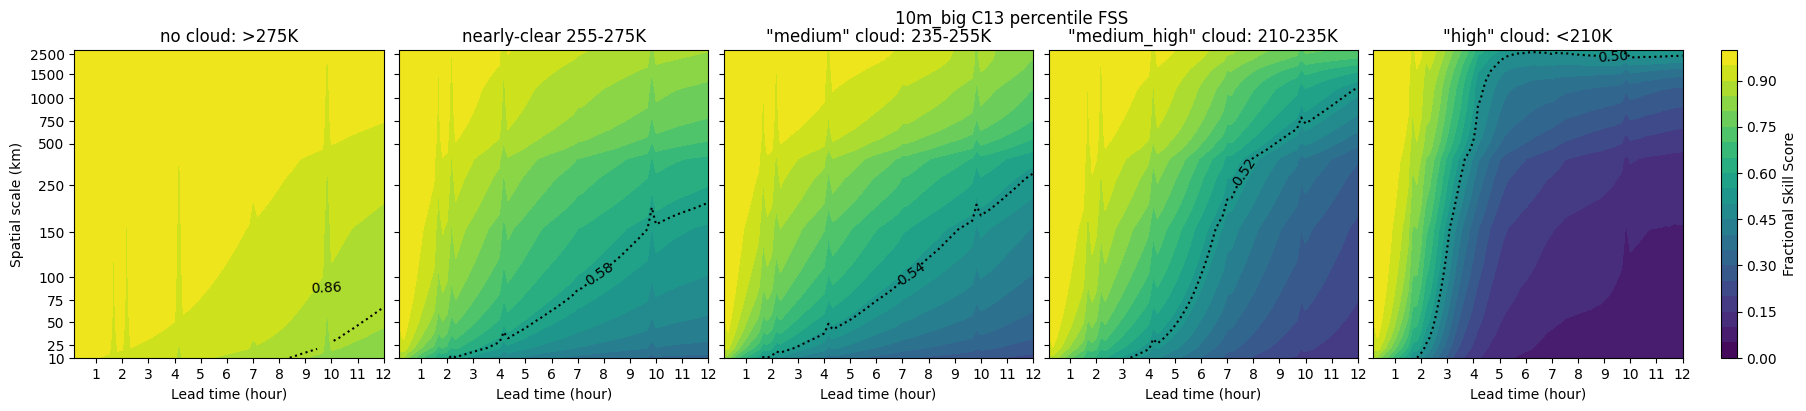

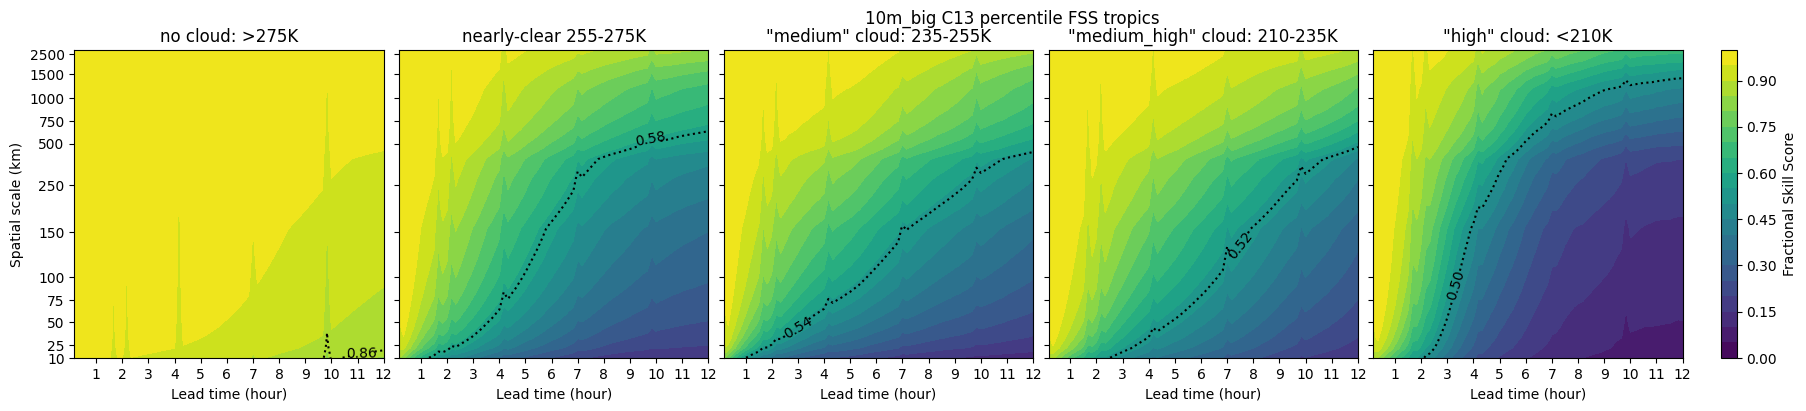

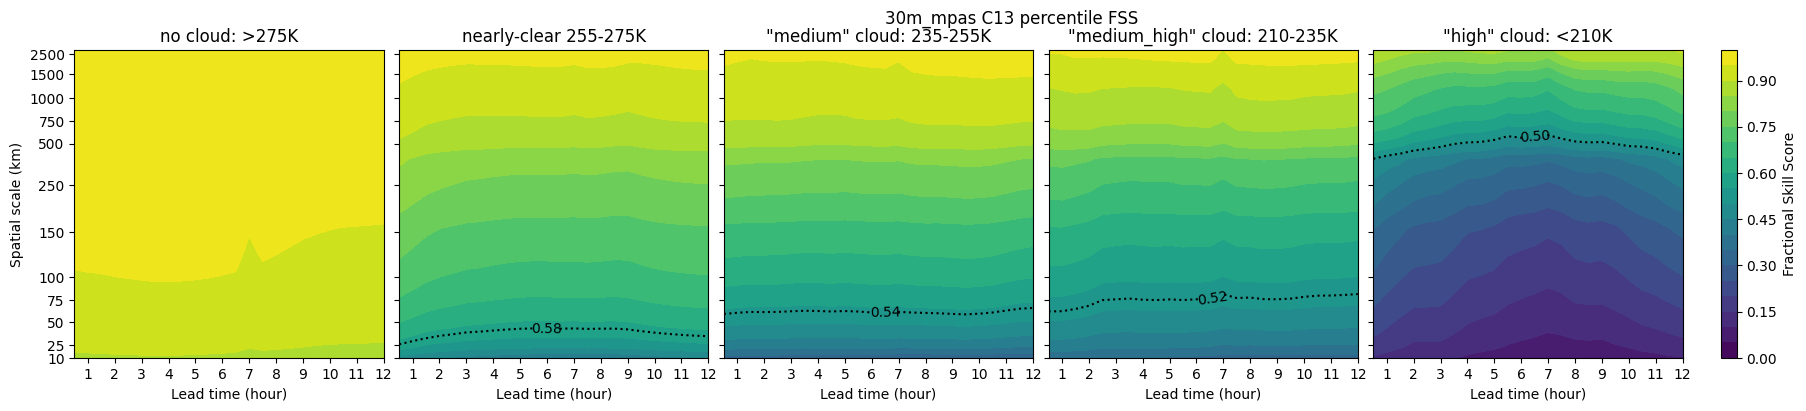

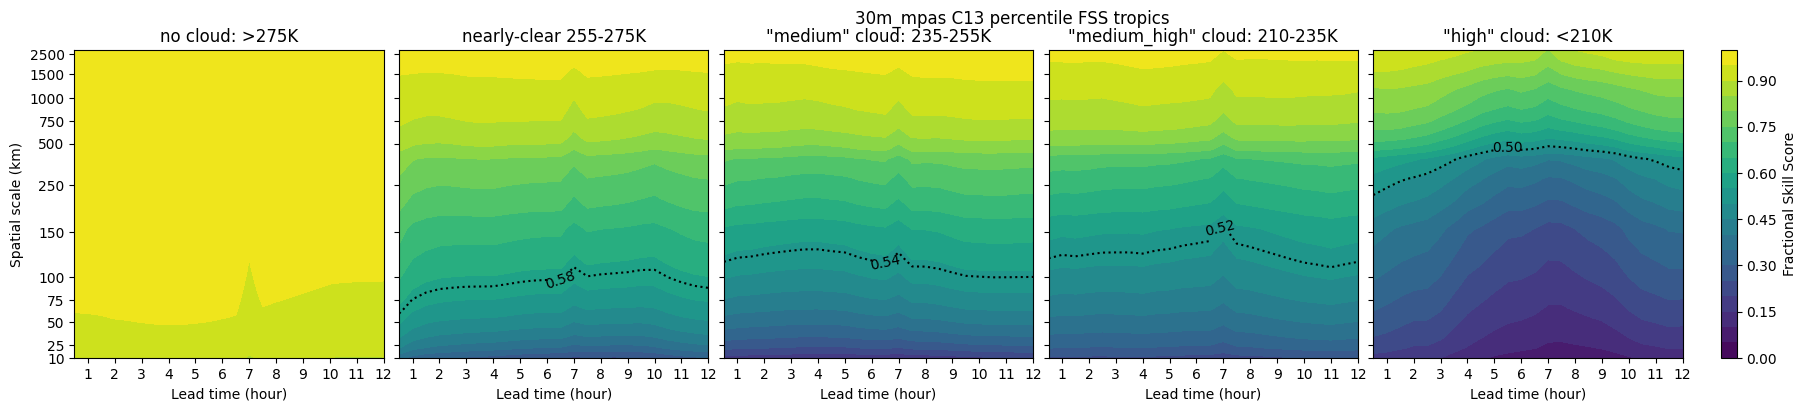

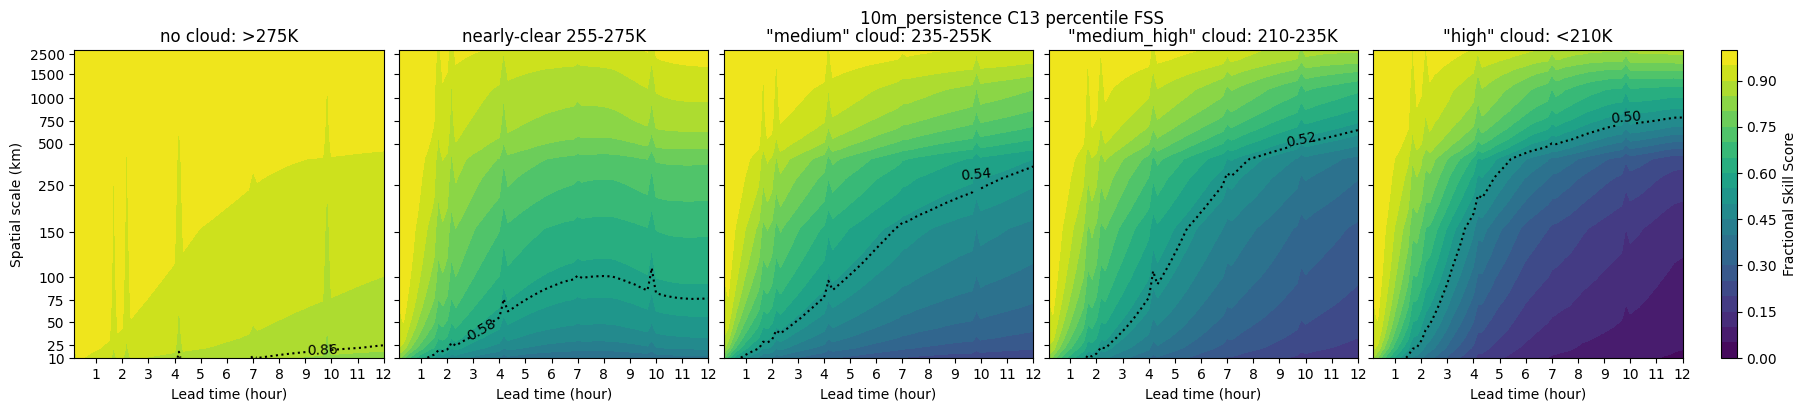

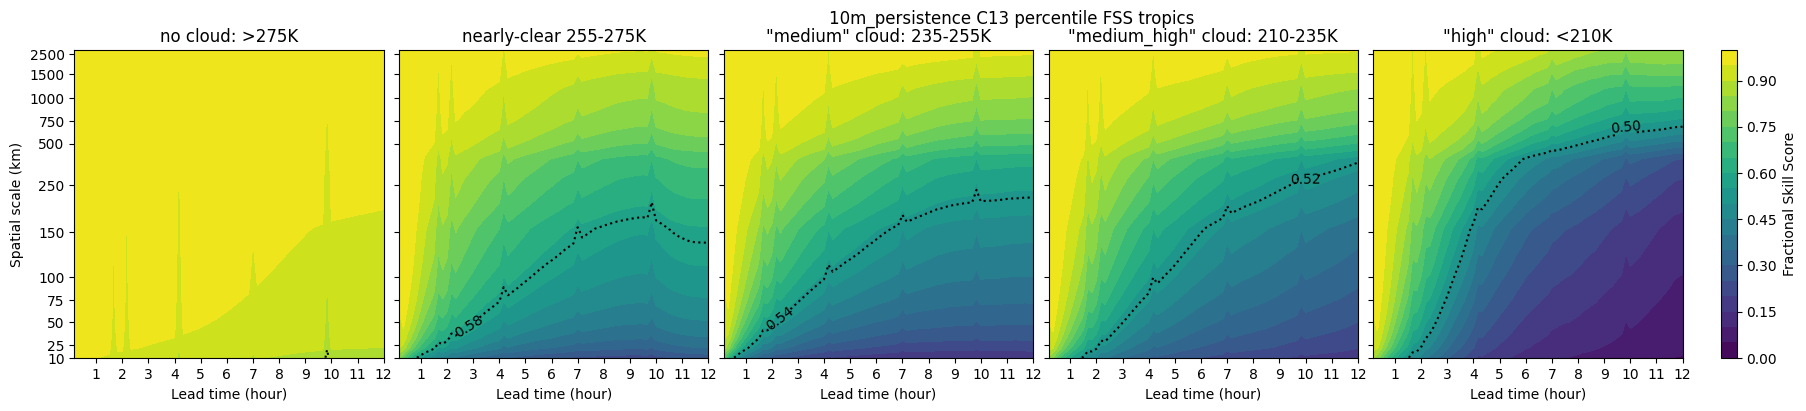

In [17]:
t = 12
for model in ["10m_big", "30m_mpas", "10m_persistence"]:
    pct=True
    fss_plot(dfs_init_time[f"{model}_{t:02}z"], int(model[:2]), 13, ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
            percentile=pct,
            suptitle=f"{model} C13 percentile FSS")
    
    tropics=True
    fss_plot(dfs_init_time[f"{model}_{t:02}z"], int(model[:2]), 13, ["none", "low", "medium", "medium_high", "high"], titles=["no cloud: >275K", '''nearly-clear 255-275K''', '''"medium" cloud: 235-255K''',  '''"medium_high" cloud: 210-235K''', '''"high" cloud: <210K'''],
            percentile=pct, tropics=tropics,
            suptitle=f"{model} C13 percentile FSS tropics")
    

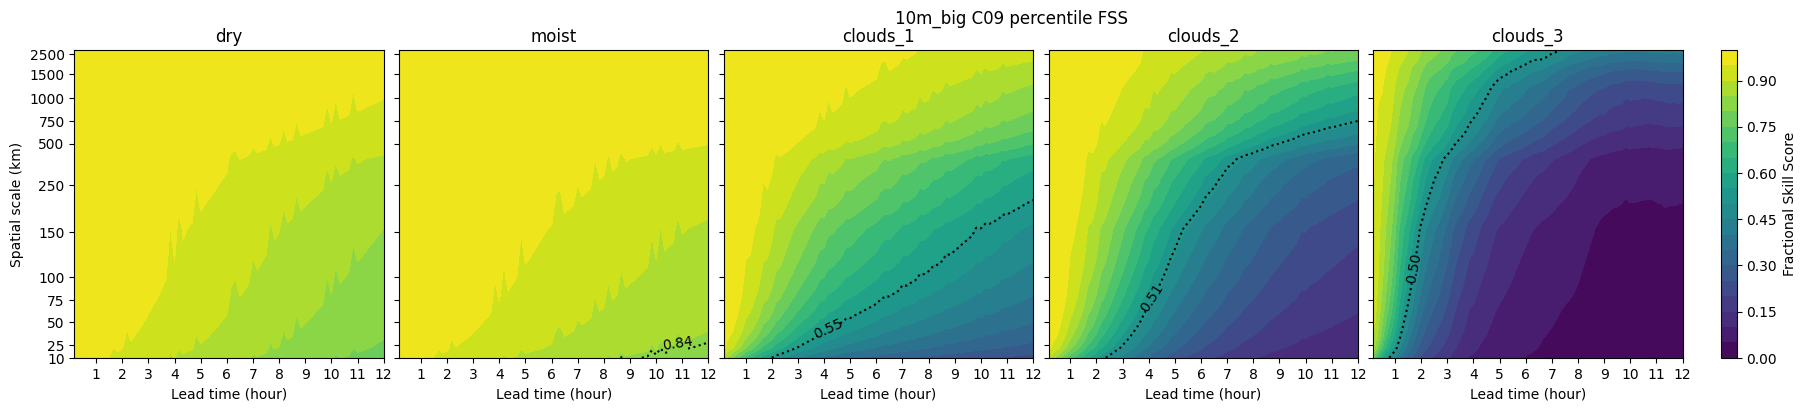

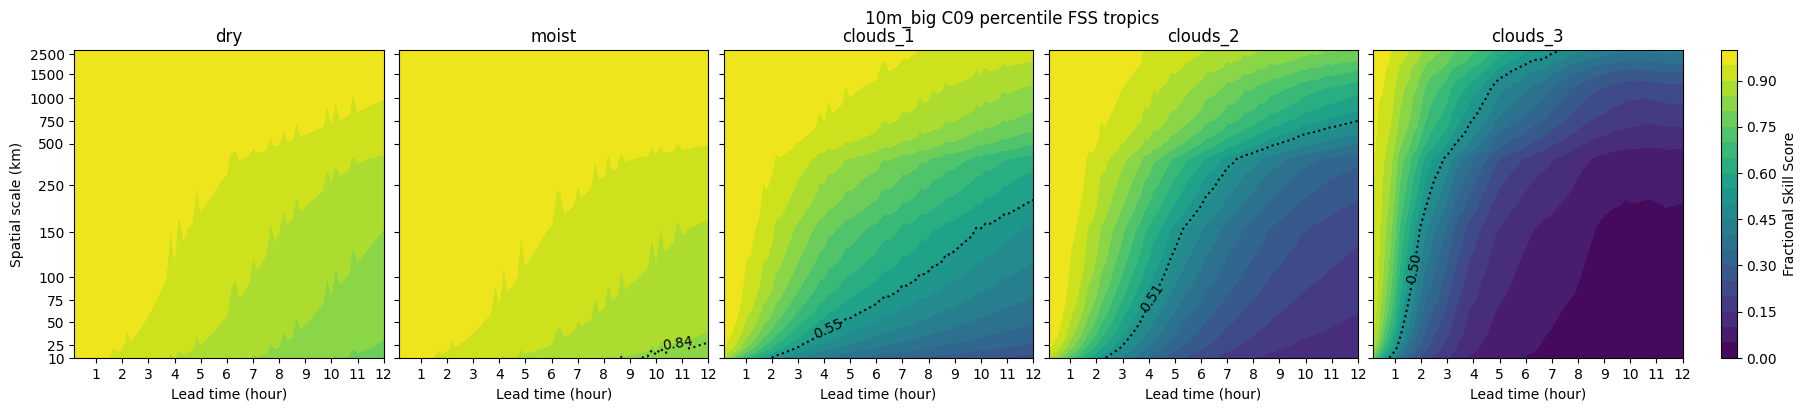

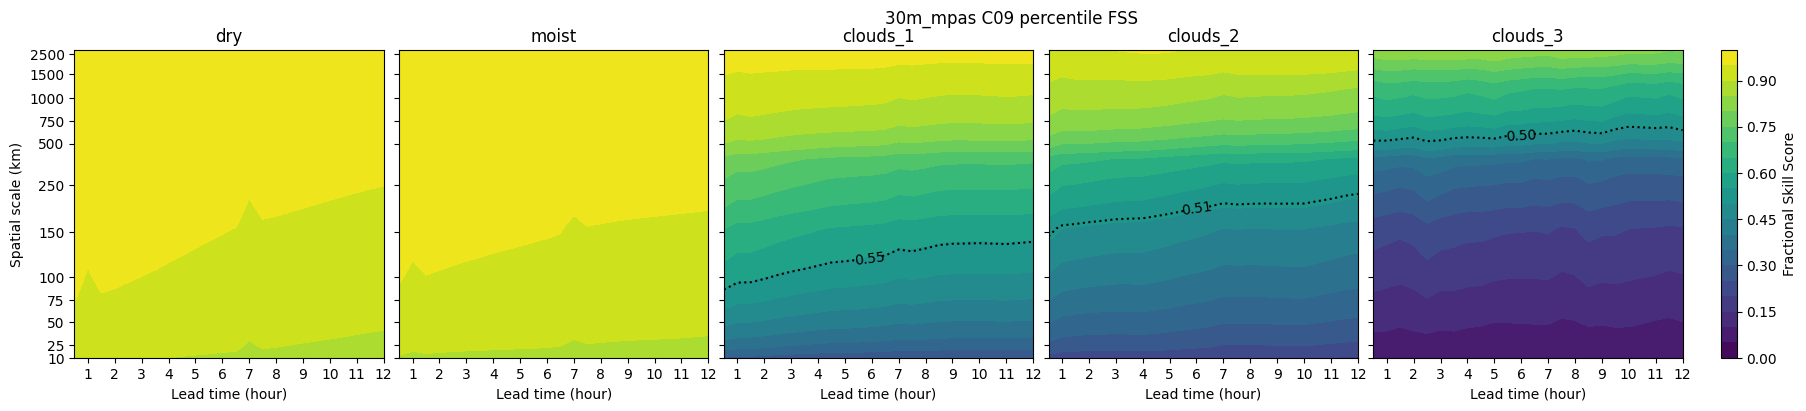

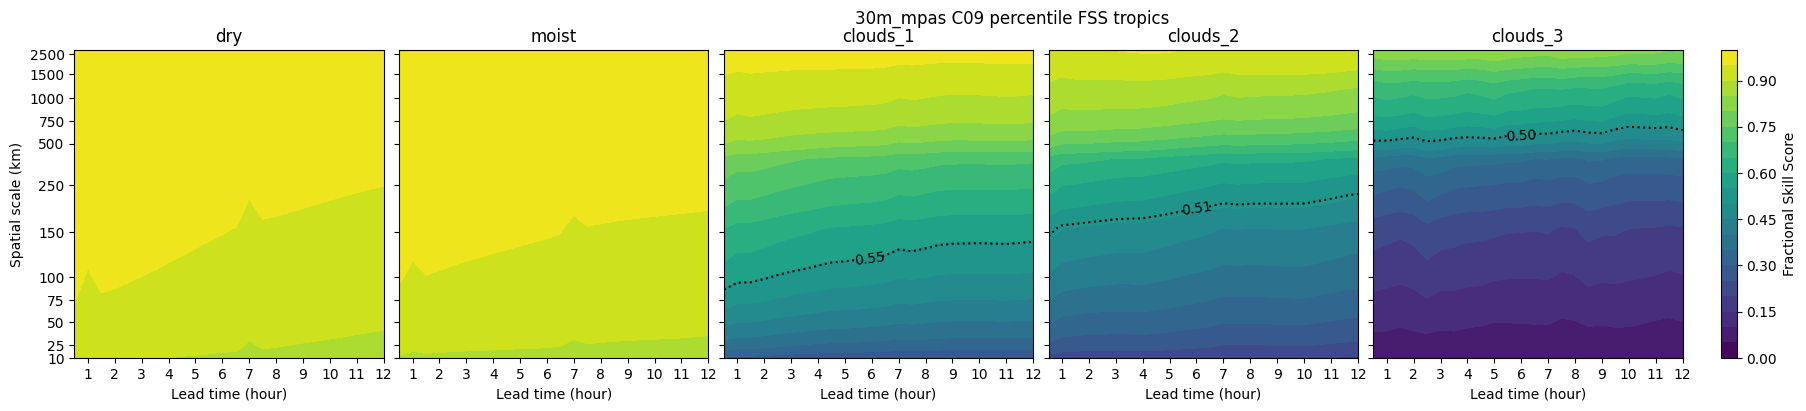

In [ ]:
for model in ["10m_big", "30m_mpas"]:
    pct = True
    fss_types = ["dry", "moist", "clouds_1", "clouds_2", "clouds_3"]
    fss_plot(dfs[model], int(model[:2]), 9, fss_types,
                titles=fss_types,
            percentile=pct, tropics=tropics,
            suptitle=f"{model} C09 percentile FSS")

    tropics = True
    fss_plot(dfs[model], int(model[:2]), 9, fss_types, 
            titles=fss_types,
            percentile=pct, tropics=tropics,
            suptitle=f"{model} C09 percentile FSS tropics")


In [ ]:
# plot 12 init thresholds

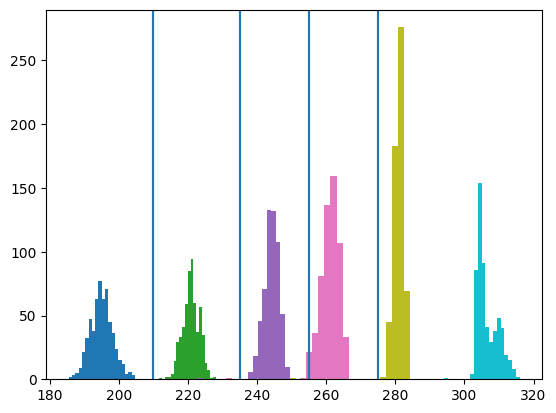

In [ ]:
# bins
import yaml
config = "/glade/u/home/dkimpara/miles-credit/config_goes/example_eval.yml"

with open(config) as cf:
    conf = yaml.load(cf, Loader=yaml.FullLoader)

all_df = [pd.read_parquet(p) for p in Path(baselines["30m_mpas"]).iterdir() if (p != "verif.parquet") and "parquet" in p.name and "T18" in p.name]
channel = 13
tropics = True
fss_conf = conf["FSS"][channel]
categories = fss_conf["sky_categories"]

for category, bin_edges in categories.items():
    col_name = f"bin_edges_C{channel:02}_PCT_{category}{"_tropics" if tropics else ""}"
    all_edges = [df[col_name] for df in all_df]
    low_edge = pd.concat(all_edges, ignore_index=True, axis=0).apply(lambda x: x[0])
    high_edge = pd.concat(all_edges, ignore_index=True, axis=0).apply(lambda x: x[1])

    plt.hist(low_edge, bins=20)
    plt.hist(high_edge, bins=20)
    if bin_edges[0] != 0:
        plt.axvline(np.clip(bin_edges[0], 150, 320))
    if bin_edges[1] != 1000:
        plt.axvline(np.clip(bin_edges[1], 150, 320))